In [3]:
import pandas as pd
import random   
from faker import Faker

fake = Faker()

categorias = ['Tecnologia', 'Ropa', 'Hogar', 'Deportes', 'ALimentos']
metodos_pago = ['Tarjeta', 'Efectivo', 'Transferencia']
Estatus = ['Completada', 'Pendiente', 'Cancelada']

data = []

for _ in range(5000):
    registro = {
        "precio": round(random.uniform(50, 5000), 2),
        "cantidad": random.randint(1, 10),
        "total": 0,  # Se calculará más adelante
        "descuento": round(random.uniform(0, 0.3), 2),  

        "categoria": random.choice(categorias),
        "metodo_pago": random.choice(metodos_pago),
        "estatus": random.choice(Estatus),

        "cliente": {
            "nombre": fake.name(),
            "correo": fake.email(),
            "ciudad": fake.city(), 
        },

        "producto": {
            "nombre": fake.word(),
            "marca": fake.company(),
            "stock": random.randint(0, 100)
        },

        "descripcion": fake.sentence(),
        "comentarios": fake.sentence(),

        "fecha": fake.date_time_this_year(),
        "estatus": random.choice(Estatus)
    }

    registro["total"] = round(registro["precio"]) * registro["cantidad"] * (1 - registro["descuento"], 2)
    data.append(registro)

    df = pd.DataFrame(data)

df.to_csv('datos.csv', index=False)

print("datos generados con exito")
print(df.head())

datos generados con exito
    precio  cantidad                                              total  \
0    96.87         1  (0.73, 2, 0.73, 2, 0.73, 2, 0.73, 2, 0.73, 2, ...   
1   341.44         6  (0.76, 2, 0.76, 2, 0.76, 2, 0.76, 2, 0.76, 2, ...   
2  4499.74        10  (0.87, 2, 0.87, 2, 0.87, 2, 0.87, 2, 0.87, 2, ...   
3  1680.88         1  (0.8200000000000001, 2, 0.8200000000000001, 2,...   
4   505.34        10  (0.74, 2, 0.74, 2, 0.74, 2, 0.74, 2, 0.74, 2, ...   

   descuento  categoria    metodo_pago    estatus  \
0       0.27      Hogar       Efectivo  Pendiente   
1       0.24       Ropa  Transferencia  Cancelada   
2       0.13  ALimentos       Efectivo  Pendiente   
3       0.18   Deportes        Tarjeta  Pendiente   
4       0.26      Hogar  Transferencia  Pendiente   

                                             cliente  \
0  {'nombre': 'Andrew Mcneil', 'correo': 'jeffrey...   
1  {'nombre': 'Victoria King', 'correo': 'james38...   
2  {'nombre': 'Christine Payne', 'co

In [4]:
from pymongo import MongoClient
import pandas as pd

client = MongoClient("mongodb://localhost:27017/")
db = client["test_db"]
coleccion = db["ventas"]

df = pd.read_csv("datos.csv")

registros = df.to_dict(orient="records")
coleccion.insert_many(registros)

print("Datos cargados en MongoDB")

Datos cargados en MongoDB


In [5]:
datos_mongo = list(coleccion.find())

df_mongo = pd.DataFrame(datos_mongo)

if "_id" in df_mongo.columns:
    df_mongo = df_mongo.drop(columns=["_id"])

print(df_mongo.head())

    precio  cantidad                                              total  \
0   370.11         7  (0.88, 2, 0.88, 2, 0.88, 2, 0.88, 2, 0.88, 2, ...   
1  3332.00         7  (0.95, 2, 0.95, 2, 0.95, 2, 0.95, 2, 0.95, 2, ...   
2  2900.31        10  (0.9299999999999999, 2, 0.9299999999999999, 2,...   
3  1275.47        10  (0.86, 2, 0.86, 2, 0.86, 2, 0.86, 2, 0.86, 2, ...   
4  4980.07         3  (0.7, 2, 0.7, 2, 0.7, 2, 0.7, 2, 0.7, 2, 0.7, ...   

   descuento   categoria metodo_pago     estatus  \
0       0.12   ALimentos    Efectivo   Cancelada   
1       0.05  Tecnologia    Efectivo  Completada   
2       0.07       Hogar    Efectivo  Completada   
3       0.14        Ropa     Tarjeta   Pendiente   
4       0.30        Ropa    Efectivo   Pendiente   

                                             cliente  \
0  {'nombre': 'Adam Davis', 'correo': 'chandlerti...   
1  {'nombre': 'Lisa Estrada', 'correo': 'oconnorl...   
2  {'nombre': 'Andrea Dougherty', 'correo': 'jade...   
3  {'nombre'

In [6]:
print(df_mongo.info())
print(df_mongo.describe())
print(df_mongo.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   precio       10000 non-null  float64
 1   cantidad     10000 non-null  int64  
 2   total        10000 non-null  str    
 3   descuento    10000 non-null  float64
 4   categoria    10000 non-null  str    
 5   metodo_pago  10000 non-null  str    
 6   estatus      10000 non-null  str    
 7   cliente      10000 non-null  str    
 8   producto     10000 non-null  str    
 9   descripcion  10000 non-null  str    
 10  comentarios  10000 non-null  str    
 11  fecha        10000 non-null  str    
dtypes: float64(2), int64(1), str(9)
memory usage: 937.6 KB
None
             precio      cantidad     descuento
count  10000.000000  10000.000000  10000.000000
mean    2517.127381      5.488800      0.150099
std     1431.457415      2.844202      0.085431
min       51.250000      1.000000      0.000000
25%     12

In [7]:
print(df_mongo["categoria"].value_counts())
print(df_mongo["metodo_pago"].value_counts())

categoria
Hogar         2033
Deportes      2029
Ropa          2000
ALimentos     1980
Tecnologia    1958
Name: count, dtype: int64
metodo_pago
Efectivo         3344
Tarjeta          3344
Transferencia    3312
Name: count, dtype: int64


In [8]:
df_mongo["fecha"] = pd.to_datetime(df_mongo["fecha"])
print(df_mongo["fecha"].min(), df_mongo["fecha"].max())

2026-01-01 02:08:11.837187 2026-03-27 08:51:45.828563


In [8]:
print("Media precio:", df_mongo["precio"].mean())
print("Mediana precio:", df_mongo["precio"].median())
print("Moda categoria:")
print(df_mongo["categoria"].mode())

Media precio: 2517.127381
Mediana precio: 2513.46
Moda categoria:
0    Hogar
Name: categoria, dtype: str


In [10]:
print(df_mongo.shape)
print(df_mongo["total"].dtype)
print(df_mongo["total"].head())
print(df_mongo["total"].isna().sum())

(10000, 12)
str
0    (0.88, 2, 0.88, 2, 0.88, 2, 0.88, 2, 0.88, 2, ...
1    (0.95, 2, 0.95, 2, 0.95, 2, 0.95, 2, 0.95, 2, ...
2    (0.9299999999999999, 2, 0.9299999999999999, 2,...
3    (0.86, 2, 0.86, 2, 0.86, 2, 0.86, 2, 0.86, 2, ...
4    (0.7, 2, 0.7, 2, 0.7, 2, 0.7, 2, 0.7, 2, 0.7, ...
Name: total, dtype: str
0


In [18]:
import pandas as pd

df_mongo["total"] = pd.to_numeric(df_mongo["total"], errors="coerce")
print(df_mongo["total"].dtype)
print(df_mongo["total"].isna().sum())

float64
10000


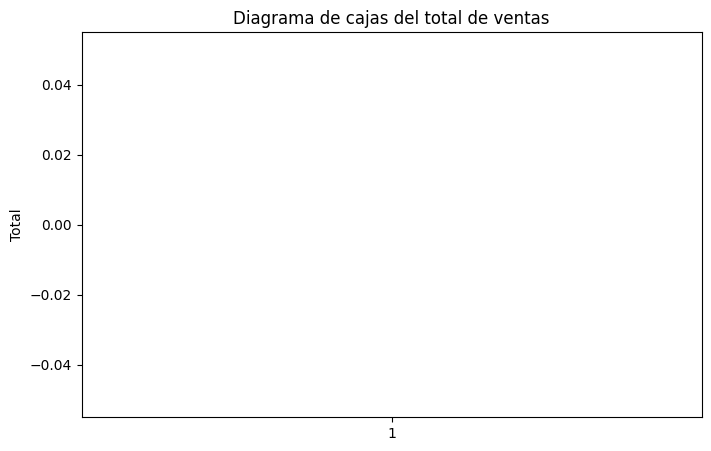

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.boxplot(df_mongo["total"])
plt.title("Diagrama de cajas del total de ventas")
plt.ylabel("Total")
plt.show()